### Run initial scripts

In [ ]:
!git clone https://github.com/k2mg5hf8/hallucination-tool-calling

fatal: destination path 'hallucination-tool-calling' already exists and is not an empty directory.


In [ ]:
%cd hallucination-tool-calling

/content/hallucination-tool-calling


In [ ]:
!python scripts/00_inspect_toolace.py

Loading ToolACE...

Dataset object:
Dataset({
    features: ['system', 'conversations'],
    num_rows: 11300
})

Column names:
['system', 'conversations']

Number of rows:
11300

First row keys and types:
- system: <class 'str'>
- conversations: <class 'list'>

First row preview:
{'conversations': [{'from': 'user',
                    'value': "I'm considering investing and I'd like to know "
                             "what's happening in the market right now. Could "
                             'you get me the top market trends in the US?'},
                   {'from': 'assistant',
                    'value': '[Market Trends API(trend_type="MARKET_INDEXES", '
                             'country="us")]'},
                   {'from': 'tool',
                    'value': '[{"name": "Market Trends API", "results": '
                             '{"trends": [{"name": "S&P 500", "description": '
                             '"Standard & Poor\'s 500 Index is a '
                      

In [ ]:
!python scripts/01_extract_base_examples.py

Extracting: 100% 11300/11300 [00:00<00:00, 19277.43it/s]

Done.
Extracted examples: 1357
Skipped rows without conversation: 0
Saved full file to: data/interim/toolace_base_clean.jsonl
Saved sample to: data/interim/toolace_base_clean_sample.jsonl

First extracted example:
{
  "id": "toolace_0_2",
  "query": "I'm considering investing and I'd like to know what's happening in the market right now. Could you get me the top market trends in the US?",
  "context": "[{\"name\": \"Market Trends API\", \"results\": {\"trends\": [{\"name\": \"S&P 500\", \"description\": \"Standard & Poor's 500 Index is a market-capitalization-weighted index of the 500 largest U.S. publicly traded companies.\", \"data\": {\"current_value\": \"4172.80\", \"percentage_change\": \"+0.68%\"}}, {\"name\": \"DOW J\", \"description\": \"Dow Jones Industrial Average is a price-weighted average of 30 blue-chip stocks that are generally the leaders in their industry.\", \"data\": {\"current_value\": \"34479.60\", \"percent

In [ ]:
!python scripts/01b_validate_extracted_examples.py

Loaded examples: 1357

Basic stats:
Avg context length: 340.1
Avg output length: 393.5
Min output length: 38
Max output length: 4016

First example:
{
  "id": "toolace_0_2",
  "query": "I'm considering investing and I'd like to know what's happening in the market right now. Could you get me the top market trends in the US?",
  "context": "[{\"name\": \"Market Trends API\", \"results\": {\"trends\": [{\"name\": \"S&P 500\", \"description\": \"Standard & Poor's 500 Index is a market-capitalization-weighted index of the 500 largest U.S. publicly traded companies.\", \"data\": {\"current_value\": \"4172.80\", \"percentage_change\": \"+0.68%\"}}, {\"name\": \"DOW J\", \"description\": \"Dow Jones Industrial Average is a price-weighted average of 30 blue-chip stocks that are generally the leaders in their industry.\", \"data\": {\"current_value\": \"34479.60\", \"percentage_change\": \"+0.47%\"}}, {\"name\": \"NASDAQ\", \"description\": \"The NASDAQ Composite is a broad-based capitalization-

In [ ]:
!python scripts/01c_make_dev_sample.py

Loaded examples: 1357
After filtering: 1353
Saved dev sample: data/interim/toolace_base_clean_dev500.jsonl


In [ ]:
!python scripts/02_inject_hallucinations.py

Loaded examples: 500
After filtering: 500

Created datasets:
Clean:          300
Conflict:       223
Overgeneration: 300
Missing tool:   300

Saved files to: data/processed

Conflict preview:
ID: toolace_331_8_conflict
QUERY: I just uploaded an appraisal report for my new bakery location, and I'd like to understand if there are any issues with it. Can you get me a validation report for order number 456-123?</
CONTEXT: [{"name": "ValidationReport", "results": {"ValidationReport": "<ValidationReport><Status>Success</Status><Details>Report validated successfully for order 456-123.</Details></ValidationReport>"}}]
OUTPUT: The appraisal report for your new bakery location, associated with order number 557-123, has been successfully validated. The report indicates that there are no issues, and everything is in order. If you need further assistance or specific details from the report, feel free to ask!
LABELS: [{'start': 80, 'end': 83, 'text': '557', 'label_type': 'Evident Conflict'}]
ID: too

In [ ]:
!python scripts/03_dataset_stats.py

Saved dataset statistics to: results/dataset_stats.csv
Saved dataset overview plot to: results/dataset_overview.png


### Load the dataset

In [ ]:
import pandas as pd

file_path = '/content/all_synthetic.jsonl' #'/content/hallucination-tool-calling/data/processed/all_synthetic.jsonl'
df_conflict = pd.read_json(file_path, lines=True)
print(f"Successfully loaded {len(df_conflict)} rows from {file_path}")
df_conflict.head()

Successfully loaded 1200 rows from /content/all_synthetic.jsonl


,id,query,context,output,tool_call,available_tools,hallucination_labels,hallucination_labels_processed,source,system,hallucination_type,original_output,corruption_types,overgeneration_clause,overgeneration_domain,overgeneration_clause_source
0,toolace_331_8_clean,I just uploaded an appraisal report for my new...,"[{""name"": ""ValidationReport"", ""results"": {""Val...",The appraisal report for your new bakery locat...,"[ValidationReport(OrderNumber=""456-123"")]",[ValidationReport],[],"{'evident_conflict': 0, 'baseless_info': 0}",ToolACE,You are an expert in composing functions. You ...,clean,NaN,NaN,NaN,NaN,NaN
1,toolace_541_2_clean,I'm writing an article on the key events and c...,"[{""name"": ""gameLore.extractEvents"", ""results"":...",King Arthur was actively involved in both the ...,"[gameLore.extractEvents(timePeriod={""startYear...",[extractEvents],[],"{'evident_conflict': 0, 'baseless_info': 0}",ToolACE,You are an expert in composing functions. You ...,clean,NaN,NaN,NaN,NaN,NaN
2,toolace_58_6_clean,"Oh, that's perfect, thanks! You know, I'm alwa...","[{""name"": ""Search WikiHow API"", ""results"": {""s...","To maintain your car efficiently, here are som...","[Search WikiHow API(q=""car maintenance schedul...",[Search WikiHow API],[],"{'evident_conflict': 0, 'baseless_info': 0}",ToolACE,You are an expert in composing functions. You ...,clean,NaN,NaN,NaN,NaN,NaN
3,toolace_453_2_clean,"Oh, magnificent digital oracle, bestow upon me...","[{""name"": ""webtoonOriginalsGenresList"", ""resul...",Here are the different genres of webtoons avai...,"[webtoonOriginalsGenresList(language=""en"")]",[webtoonOriginalsGenresList],[],"{'evident_conflict': 0, 'baseless_info': 0}",ToolACE,You are an expert in composing functions. You ...,clean,NaN,NaN,NaN,NaN,NaN
4,toolace_769_2_clean,I'm researching the effects of a specific CRIS...,"[{""name"": ""gene.editing_simulation"", ""results""...",The predicted 3D structure of the modified BRC...,"[gene.editing_simulation(gene_id=""geneBRCA1"", ...",[editing_simulation],[],"{'evident_conflict': 0, 'baseless_info': 0}",ToolACE,You are an expert in composing functions. You ...,clean,NaN,NaN,NaN,NaN,NaN


### LettuceDetect

In [ ]:
!pip install lettucedetect

In [ ]:
# !pip install --force-reinstall numpy==1.26.4
import pandas as pd
import os
import json
from lettucedetect.models.inference import HallucinationDetector
from tqdm.notebook import tqdm
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
detector = HallucinationDetector(
    method="transformer", model_path="KRLabsOrg/lettucedect-base-modernbert-en-v1"
)

evaluation_results = []

print(f"Evaluating {len(df_conflict)} examples from conflict.jsonl...")

for index, row in tqdm(df_conflict.iterrows(), total=len(df_conflict), desc="Processing examples"):
    example_id = row['id']
    question = row['query']
    answer = row['output']
    original_hallucination_labels = row['hallucination_labels']

    tool_results_list = json.loads(row['context'])
    contexts_for_detector = [json.dumps(res, ensure_ascii=False, indent=2) for res in tool_results_list]

    if not contexts_for_detector:
        current_predictions = []
        error_message = "Empty context provided to detector."
        print(f"Warning: {error_message} for example {example_id}.") # Optional: print warnings
    else:
        try:
            current_predictions = detector.predict(
                context=contexts_for_detector,
                question=question,
                answer=answer,
                output_format="spans" #spans
            )
            error_message = None
        except Exception as e:
            current_predictions = []
            error_message = f"Error during prediction: {e}"
            print(f"Error predicting for example {example_id}: {e}")

    evaluation_results.append({
        'id': example_id,
        'question': question,
        'answer': answer,
        'context':contexts_for_detector,
        'detector_predictions': current_predictions,
        'original_hallucination_labels': original_hallucination_labels,
        'error': error_message
    })

print("\nEvaluation complete. Displaying first 5 results:")
for i, result in enumerate(evaluation_results[:5]):
    print(f"--- Example ID: {result['id']} ---")
    print(f"Question: {result['question']}")
    print(f"Context: {result['context']}")
    print(f"Answer: {result['answer']}")
    print(f"Detector Predictions: {result['detector_predictions']}")
    print(f"Original Labels: {result['original_hallucination_labels']}")
    if result['error']:
        print(f"Error: {result['error']}")
    print("-" * 30)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.58M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

Evaluating 1200 examples from conflict.jsonl...


Processing examples:   0%|          | 0/1200 [00:00<?, ?it/s]

W0526 20:39:16.888000 3757 torch/_inductor/utils.py:1731] [1/0_1] Not enough SMs to use max_autotune_gemm mode



Evaluation complete. Displaying first 5 results:
--- Example ID: toolace_331_8_clean ---
Question: I just uploaded an appraisal report for my new bakery location, and I'd like to understand if there are any issues with it. Can you get me a validation report for order number 456-123?</
Context: ['{\n  "name": "ValidationReport",\n  "results": {\n    "ValidationReport": "<ValidationReport><Status>Success</Status><Details>Report validated successfully for order 456-123.</Details></ValidationReport>"\n  }\n}']
Answer: The appraisal report for your new bakery location, associated with order number 456-123, has been successfully validated. The report indicates that there are no issues, and everything is in order. If you need further assistance or specific details from the report, feel free to ask!
Detector Predictions: [{'start': 172, 'end': 183, 'confidence': 0.5752647519111633, 'text': ' everything'}, {'start': 186, 'end': 195, 'confidence': 0.5454884767532349, 'text': ' in order'}]
Origi

In [ ]:
output_dir = "results"
os.makedirs(output_dir, exist_ok=True)
output_file_path = os.path.join(output_dir, 'eval_lettuce_all.json')
with open(output_file_path, 'w', encoding='utf-8') as f:
    json.dump(evaluation_results, f, indent=4, ensure_ascii=False)
print(f"\nFull evaluation results saved to {output_file_path}")


Full evaluation results saved to results/eval_lettuce_all.json


### Analytics

##### Sentence level

In [ ]:
example_labels = []
example_preds = []
categories = []

for i, result in tqdm(enumerate(evaluation_results), desc="Processing for example-level metrics"):
    true_example_label = 1 if result['original_hallucination_labels'] else 0
    example_labels.append(true_example_label)

    pred_example_label = 1 if len(result['detector_predictions']) > 0 else 0
    example_preds.append(pred_example_label) # Added this line

    categories.append(df_conflict.loc[i]['hallucination_type'])


precision, recall, f1, _ = precision_recall_fscore_support(
    example_labels, example_preds, labels=[0, 1], average=None, zero_division=0
)

print("\n--- Example-Level Metrics (based on whether *any* hallucination is present) ---")
print(f"Total examples evaluated: {len(example_labels)}")


tp = sum(1 for i in range(len(example_labels)) if example_labels[i] == 1 and example_preds[i] == 1)
fp = sum(1 for i in range(len(example_labels)) if example_labels[i] == 0 and example_preds[i] == 1)
fn = sum(1 for i in range(len(example_labels)) if example_labels[i] == 1 and example_preds[i] == 0)
tn = sum(1 for i in range(len(example_labels)) if example_labels[i] == 0 and example_preds[i] == 0)

print("\n--- Confusion Matrix ---")
print(f"{'':<18} | {'Predicted Positive':<20} | {'Predicted Negative':<20}")
print(f"{'-'*18}-+-{'-'*20}-+-{'-'*20}")
print(f"{'Actual Positive':<18} | {tp:<20} | {fn:<20}")
print(f"{'Actual Negative':<18} | {fp:<20} | {tn:<20}")

print("\nMetrics for Class 0 (Not Hallucinated):")
print(f"  Precision: {precision[0]:.4f}")
print(f"  Recall: {recall[0]:.4f}")
print(f"  F1-Score: {f1[0]:.4f}")

print("\nMetrics for Class 1 (Hallucinated):")
print(f"  Precision: {precision[1]:.4f}")
print(f"  Recall: {recall[1]:.4f}")
print(f"  F1-Score: {f1[1]:.4f}")

Processing for example-level metrics: 0it [00:00, ?it/s]


--- Example-Level Metrics (based on whether *any* hallucination is present) ---
Total examples evaluated: 1200

--- Confusion Matrix ---
                   | Predicted Positive   | Predicted Negative  
-------------------+----------------------+---------------------
Actual Positive    | 684                  | 216                 
Actual Negative    | 174                  | 126                 

Metrics for Class 0 (Not Hallucinated):
  Precision: 0.3684
  Recall: 0.4200
  F1-Score: 0.3925

Metrics for Class 1 (Hallucinated):
  Precision: 0.7972
  Recall: 0.7600
  F1-Score: 0.7782


In [ ]:
df_examples = pd.DataFrame({
    'true_label': example_labels,
    'predicted_label': example_preds,
    'category': categories
})

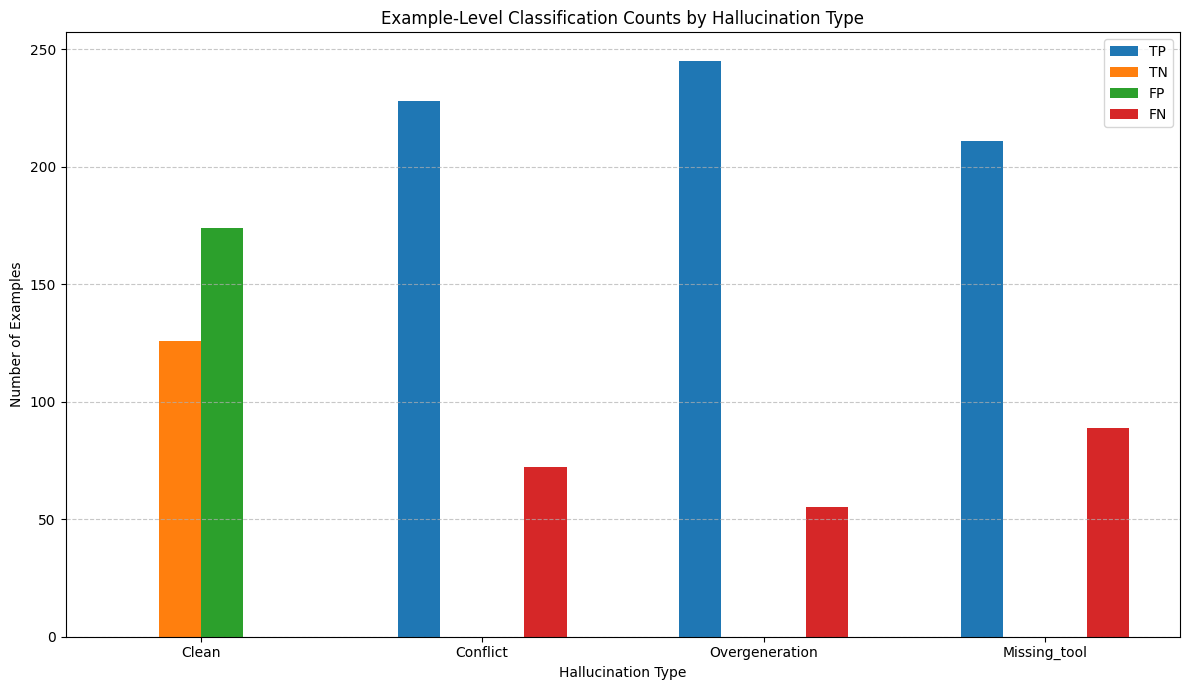

In [ ]:
classification_data_for_plot = {}
for category_name in df_examples['category'].unique():
    subset_df = df_examples[df_examples['category'] == category_name]
    tp = len(subset_df[(subset_df['true_label'] == 1) & (subset_df['predicted_label'] == 1)])
    tn = len(subset_df[(subset_df['true_label'] == 0) & (subset_df['predicted_label'] == 0)])
    fp = len(subset_df[(subset_df['true_label'] == 0) & (subset_df['predicted_label'] == 1)])
    fn = len(subset_df[(subset_df['true_label'] == 1) & (subset_df['predicted_label'] == 0)])
    classification_data_for_plot[category_name] = {'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn}

metrics_labels = ['TP', 'TN', 'FP', 'FN']
h_types = list(classification_data_for_plot.keys())
num_types = len(h_types)
bar_width = 0.15
index = np.arange(num_types)

fig, ax = plt.subplots(figsize=(12, 7))

for i, metric in enumerate(metrics_labels):
    values = [classification_data_for_plot[h_type][metric] for h_type in h_types]
    ax.bar(index + i * bar_width, values, bar_width, label=metric)

ax.set_xlabel('Hallucination Type')
ax.set_ylabel('Number of Examples')
ax.set_title('Example-Level Classification Counts by Hallucination Type')
ax.set_xticks(index + bar_width * (len(metrics_labels) - 1) / 2)
ax.set_xticklabels([h_type.capitalize() for h_type in h_types])
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Examples of Wrongly Classified Predictions ---")
wrongly_classified_df = df_examples[df_examples['true_label'] != df_examples['predicted_label']]

# Map example index to full example details using evaluation_results and df_conflict
id_to_full_example = {res['id']: res for res in evaluation_results}

for idx, row in wrongly_classified_df.iterrows():
    original_id = df_conflict.loc[idx, 'id'] # Get the original 'id' from df_conflict using the index
    full_example = id_to_full_example.get(original_id)

    if full_example:
        print(f"\nExample ID: {original_id}")
        print(f"Category: {row['category']}")
        print(f"True Label (1=Hallucinated, 0=Not Hallucinated): {row['true_label']}")
        print(f"Predicted Label (1=Hallucinated, 0=Not Hallucinated): {row['predicted_label']}")
        print(f"Question: {full_example['question'][:150]}...") # Truncate for readability
        print(f"Tool output: {full_example['context']}") # Corrected from result['context']
        print(f"Answer: {full_example['answer'][:1000]}...") # Truncate for readability
        print(f"Original Hallucination Labels: {full_example['original_hallucination_labels']}")
        # Corrected from iterating full_example directly to iterating full_example['detector_predictions']
        print(f"Detected spans: {[span['text'] for span in full_example['detector_predictions']]}")
        print("-" * 50)
    else:
        print(f"Could not find full example for index {idx} with ID {original_id}")


--- Examples of Wrongly Classified Predictions ---

Example ID: toolace_331_8_clean
Category: clean
True Label (1=Hallucinated, 0=Not Hallucinated): 0
Predicted Label (1=Hallucinated, 0=Not Hallucinated): 1
Question: I just uploaded an appraisal report for my new bakery location, and I'd like to understand if there are any issues with it. Can you get me a validatio...
Tool output: ['{\n  "name": "ValidationReport",\n  "results": {\n    "ValidationReport": "<ValidationReport><Status>Success</Status><Details>Report validated successfully for order 456-123.</Details></ValidationReport>"\n  }\n}']
Answer: The appraisal report for your new bakery location, associated with order number 456-123, has been successfully validated. The report indicates that there are no issues, and everything is in order. If you need further assistance or specific details from the report, feel free to ask!...
Original Hallucination Labels: []
Detected spans: [' everything', ' in order']
-------------------------

##### Spans level

In [ ]:
def calculate_metrics_from_evaluation_results(evaluation_results_list):
    total_overlap = 0
    total_predicted = 0
    total_gold = 0

    for result in tqdm(evaluation_results_list, desc="Calculating metrics"):

        predicted_spans = result['detector_predictions']
        gold_spans = result['original_hallucination_labels']

        sample_predicted_length = sum(pred["end"] - pred["start"] for pred in predicted_spans)
        total_predicted += sample_predicted_length

        sample_gold_length = sum(gold["end"] - gold["start"] for gold in gold_spans)
        total_gold += sample_gold_length

        sample_overlap = 0
        for pred in predicted_spans:
            for gold in gold_spans:
                overlap_start = max(pred["start"], gold["start"])
                overlap_end = min(pred["end"], gold["end"])
                if overlap_end > overlap_start:
                    sample_overlap += overlap_end - overlap_start
        total_overlap += sample_overlap

    precision = total_overlap / total_predicted if total_predicted > 0 else 0
    recall = total_overlap / total_gold if total_gold > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return {"precision": precision, "recall": recall, "f1": f1}

overall_metrics = calculate_metrics_from_evaluation_results(evaluation_results)

print("\nOverall Character-Level Metrics:")
print(overall_metrics)

Calculating metrics:   0%|          | 0/1200 [00:00<?, ?it/s]


Overall Character-Level Metrics:
{'precision': 0.1746616735025461, 'recall': 0.4515881147540984, 'f1': 0.2518967266284702}


## Baseline on Updated Dataset (`all_synthetic_new.jsonl`)
Re-run baseline evaluation on the improved dataset: richer conflict corruptions, LLM-generated overgeneration clauses.

In [ ]:
from io import StringIO
import pandas as pd
file_path_new = '/content/all_synthetic.jsonl'
with open(file_path_new) as _f:
    df_new = pd.read_json(StringIO(_f.read()), lines=True)
print(f'Loaded {len(df_new)} rows | distribution:')
print(df_new['hallucination_type'].value_counts().to_string())
df_new.head(2)

Loaded 1200 rows | distribution:
hallucination_type
clean             300
conflict          300
overgeneration    300
missing_tool      300


,id,query,context,output,tool_call,available_tools,hallucination_labels,hallucination_labels_processed,source,system,hallucination_type,original_output,corruption_types,overgeneration_clause,overgeneration_domain,overgeneration_clause_source
0,toolace_331_8_clean,I just uploaded an appraisal report for my new...,"[{""name"": ""ValidationReport"", ""results"": {""Val...",The appraisal report for your new bakery locat...,"[ValidationReport(OrderNumber=""456-123"")]",[ValidationReport],[],"{'evident_conflict': 0, 'baseless_info': 0}",ToolACE,You are an expert in composing functions. You ...,clean,NaN,NaN,NaN,NaN,NaN
1,toolace_541_2_clean,I'm writing an article on the key events and c...,"[{""name"": ""gameLore.extractEvents"", ""results"":...",King Arthur was actively involved in both the ...,"[gameLore.extractEvents(timePeriod={""startYear...",[extractEvents],[],"{'evident_conflict': 0, 'baseless_info': 0}",ToolACE,You are an expert in composing functions. You ...,clean,NaN,NaN,NaN,NaN,NaN


In [ ]:
evaluation_results_new = []

for index, row in tqdm(df_new.iterrows(), total=len(df_new), desc='Baseline on new dataset'):
    example_id  = row['id']
    question    = row['query']
    answer      = row['output']
    orig_labels = row['hallucination_labels']
    contexts    = [json.dumps(r, ensure_ascii=False, indent=2)
                   for r in json.loads(row['context'])]
    try:
        preds = detector.predict(context=contexts, question=question,
                                 answer=answer, output_format='spans')
        err   = None
    except Exception as e:
        preds = []; err = str(e)
    evaluation_results_new.append({
        'id': example_id, 'question': question, 'answer': answer,
        'context': contexts, 'detector_predictions': preds,
        'original_hallucination_labels': orig_labels, 'error': err
    })

ex_labels_new, ex_preds_new, cats_new = [], [], []
for i, res in enumerate(evaluation_results_new):
    ex_labels_new.append(1 if res['original_hallucination_labels'] else 0)
    ex_preds_new.append(1 if len(res['detector_predictions']) > 0 else 0)
    cats_new.append(df_new.loc[i, 'hallucination_type'])

tp_n = sum(l==1 and p==1 for l,p in zip(ex_labels_new, ex_preds_new))
fp_n = sum(l==0 and p==1 for l,p in zip(ex_labels_new, ex_preds_new))
fn_n = sum(l==1 and p==0 for l,p in zip(ex_labels_new, ex_preds_new))
tn_n = sum(l==0 and p==0 for l,p in zip(ex_labels_new, ex_preds_new))
prec_h = tp_n/(tp_n+fp_n+1e-9); rec_h = tp_n/(tp_n+fn_n+1e-9)
f1_h   = 2*prec_h*rec_h/(prec_h+rec_h+1e-9)
prec_c = tn_n/(tn_n+fn_n+1e-9); rec_c = tn_n/(tn_n+fp_n+1e-9)
f1_c   = 2*prec_c*rec_c/(prec_c+rec_c+1e-9)
print(f'Baseline (new dataset)  TP={tp_n} FP={fp_n} FN={fn_n} TN={tn_n}')
print(f'Class 0 (clean)  P={prec_c:.4f}  R={rec_c:.4f}  F1={f1_c:.4f}')
print(f'Class 1 (hallu)  P={prec_h:.4f}  R={rec_h:.4f}  F1={f1_h:.4f}')
baseline_span_new = calculate_metrics_from_evaluation_results(evaluation_results_new)
print(f'Span-level  P={baseline_span_new["precision"]:.4f}  '
      f'R={baseline_span_new["recall"]:.4f}  F1={baseline_span_new["f1"]:.4f}')

Baseline on new dataset:   0%|          | 0/1200 [00:00<?, ?it/s]

Baseline (new dataset)  TP=684 FP=174 FN=216 TN=126
Class 0 (clean)  P=0.3684  R=0.4200  F1=0.3925
Class 1 (hallu)  P=0.7972  R=0.7600  F1=0.7782


Calculating metrics:   0%|          | 0/1200 [00:00<?, ?it/s]

Span-level  P=0.1747  R=0.4516  F1=0.2519


## Train / Val / Test Split
Stratified 70 / 15 / 15 by hallucination type. Test set is held out — only used for final evaluation.

In [ ]:
from sklearn.model_selection import train_test_split

train_df, _temp = train_test_split(
    df_new, test_size=0.30, stratify=df_new['hallucination_type'], random_state=42)
val_df, test_df = train_test_split(
    _temp,  test_size=0.50, stratify=_temp['hallucination_type'], random_state=42)

print(f'Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}')
for name, sdf in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'{name}:', sdf['hallucination_type'].value_counts().to_dict())


Train 840 | Val 180 | Test 180
Train: {'missing_tool': 210, 'overgeneration': 210, 'conflict': 210, 'clean': 210}
Val: {'overgeneration': 45, 'conflict': 45, 'clean': 45, 'missing_tool': 45}
Test: {'overgeneration': 45, 'conflict': 45, 'missing_tool': 45, 'clean': 45}


In [ ]:
train_df.to_json('train.jsonl', orient='records', lines=True, force_ascii=False)
val_df.to_json('val.jsonl',   orient='records', lines=True, force_ascii=False)
test_df.to_json('test.jsonl',  orient='records', lines=True, force_ascii=False)
print('Saved train / val / test .jsonl')

Saved train / val / test .jsonl


## Fine-tuning LettuceDetect on Tool-Calling Data
Load the pretrained ModernBERT checkpoint, freeze the first 18 encoder layers, unfreeze the last 4 layers + classifier head (~20% trainable params). Train token-classification on our tool-calling split.

In [ ]:
!pip install transformers datasets accelerate -q
import torch, re, inspect
from transformers import AutoTokenizer, AutoModelForTokenClassification

MODEL_NAME = 'KRLabsOrg/lettucedect-base-modernbert-en-v1'
MAX_LEN    = 2048
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

tokenizer_ft = AutoTokenizer.from_pretrained(MODEL_NAME)

from lettucedetect.models.inference import HallucinationDetector as _HD
_src = inspect.getsource(_HD.predict)
print('=== predict() source (first 60 lines) ===')
for ln in _src.splitlines()[:60]:
    print(ln)

Device: cuda
=== predict() source (first 60 lines) ===
    def predict(
        self,
        context: list[str],
        answer: str,
        question: str | None = None,
        output_format: str = "tokens",
    ) -> list:
        """Predict hallucination tokens or spans given passages and an answer.

        This is the call most RAG pipelines use.

        See the concrete detector docs for the structure of the returned list.
        """
        return self.detector.predict(context, answer, question, output_format)


In [ ]:
import torch
from torch.utils.data import Dataset


def build_input(contexts, question, answer):
    """Return (full_text, answer_start_char)."""
    prefix = 'Contexts:\n' + '\n---\n'.join(contexts) + f'\n\nQuestion: {question}\n\nAnswer: '
    return prefix + answer, len(prefix)


def encode_example(row, tokenizer, max_len=MAX_LEN):
    try:
        ctx_list = json.loads(row['context'])
        contexts = [json.dumps(c, ensure_ascii=False, indent=2) for c in ctx_list]
    except Exception:
        contexts = [str(row['context'])]

    answer   = row['output']
    labels   = row['hallucination_labels'] if isinstance(row['hallucination_labels'], list) else []
    full_text, ans_start = build_input(contexts, row['query'], answer)

    enc = tokenizer(
        full_text, max_length=max_len, truncation=True,
        padding='max_length', return_tensors='pt',
        return_offsets_mapping=True
    )

    char_lbl = [0] * len(answer)
    for span in labels:
        for i in range(span.get('start', 0), min(span.get('end', 0), len(char_lbl))):
            char_lbl[i] = 1

    tok_labels = []
    token_weights = [] # Initialize token_weights
    example_hallucination_type = row['hallucination_type'] # Get the example-level hallucination type

    for ts, te in enc.offset_mapping[0].tolist():
        if ts == te: # Special tokens or padding outside of actual text range
            tok_labels.append(-100)
            token_weights.append(0.0)
        elif te <= ans_start: # Tokens in context/question, not part of the answer
            tok_labels.append(-100)
            token_weights.append(0.0)
        else: # Tokens within the answer
            cp = ts - ans_start
            label = char_lbl[cp] if 0 <= cp < len(char_lbl) else -100
            tok_labels.append(label)

            if label == 1: # Hallucinated token
                if example_hallucination_type == 'conflict':
                    token_weights.append(1.5) # Apply 1.5 weight for conflict hallucinations
                else:
                    token_weights.append(1.0) # Default weight for other hallucination types
            elif label == 0: # Non-hallucinated token
                token_weights.append(1.0) # Default weight for non-hallucinated tokens
            else: # label is -100 (e.g., token spans across a boundary where char_lbl was out of range)
                token_weights.append(0.0) # Ignore these tokens for weighting

    return {
        'input_ids':      enc['input_ids'].squeeze(),
        'attention_mask': enc['attention_mask'].squeeze(),
        'labels':         torch.tensor(tok_labels[:max_len], dtype=torch.long),
        'token_weights':  torch.tensor(token_weights[:max_len], dtype=torch.float) # Add token_weights
    }


class HalluDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=MAX_LEN):
        self.df, self.tok, self.max_len = df.reset_index(drop=True), tokenizer, max_len
    def __len__(self): return len(self.df)
    def __getitem__(self, i): return encode_example(self.df.iloc[i], self.tok, self.max_len)


train_ds = HalluDataset(train_df, tokenizer_ft)
val_ds   = HalluDataset(val_df,   tokenizer_ft)
test_ds  = HalluDataset(test_df,  tokenizer_ft)
print(f'Train {len(train_ds)} | Val {len(val_ds)} | Test {len(test_ds)}')
sample = train_ds[0]
print('input_ids shape:', sample['input_ids'].shape)
print('non-masked labels:', (sample['labels'] != -100).sum().item())

Train 840 | Val 180 | Test 180
input_ids shape: torch.Size([2048])
non-masked labels: 262


In [ ]:
model_ft = AutoModelForTokenClassification.from_pretrained(MODEL_NAME).to(DEVICE)

all_param_names = [n for n, _ in model_ft.named_parameters()]
layer_nums = sorted({int(m) for n in all_param_names
                      for m in re.findall(r'\.layers?\.?(\d+)\.', n)})
total_layers = max(layer_nums) + 1 if layer_nums else 0
print(f'Encoder layers: {total_layers}  (indices 0-{total_layers-1})')

N_UNFREEZE   = 4
freeze_up_to = total_layers - N_UNFREEZE

for param in model_ft.parameters():
    param.requires_grad = False

for name, param in model_ft.named_parameters():
    ms = re.findall(r'\.layers?\.?(\d+)\.', name)
    layer_idx = int(ms[0]) if ms else -1
    if layer_idx >= freeze_up_to or 'classifier' in name:
        param.requires_grad = True

trainable = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in model_ft.parameters())
print(f'Trainable: {trainable:,} / {total_p:,}  ({100*trainable/total_p:.1f}%)')

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

Encoder layers: 22  (indices 0-21)
Trainable: 20,061,698 / 149,606,402  (13.4%)


In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorForTokenClassification
from sklearn.metrics import precision_recall_fscore_support
import torch.nn as nn
import torch
import numpy as np # Import numpy

def compute_metrics(eval_pred):
    logits, label_info = eval_pred # Unpack to label_info, which is expected to be a tuple (labels, token_weights)
    labels = label_info[0] # Get the actual labels from the tuple
    preds  = np.argmax(logits, axis=2)

    # Ensure labels is a numpy array (it should be from EvalPrediction, but explicit conversion adds robustness)
    if not isinstance(labels, np.ndarray):
        labels = labels.cpu().numpy() # Assuming it's a torch tensor if not a numpy array

    # Flatten labels and predictions, and filter out ignored indices (-100)
    labels_flat = labels.flatten()
    preds_flat = preds.flatten()

    # Use boolean indexing to filter out tokens with label -100
    valid_indices = (labels_flat != -100)

    y_true = labels_flat[valid_indices]
    y_pred = preds_flat[valid_indices]

    p_, r_, f_, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0)
    return {'precision': p_, 'recall': r_, 'f1': f_}


class CustomDataCollatorForTokenClassification(DataCollatorForTokenClassification):
    def __call__(self, features):
        # Extract token_weights first
        token_weights_list = []
        processed_features = []
        for feature in features:
            if 'token_weights' in feature:
                token_weights_list.append(feature.pop('token_weights'))
            processed_features.append(feature)

        # Call the superclass's __call__ method with the processed features
        batch = super().__call__(processed_features)

        # If token_weights were extracted, pad and add them to the batch
        if token_weights_list:
            max_len = max(len(w) for w in token_weights_list)
            padded_weights = []
            for w in token_weights_list:
                if len(w) < max_len:
                    # Pad with 0.0, as these positions will have label -100 and won't contribute to loss
                    padded_weights.append(torch.cat([w, torch.zeros(max_len - len(w), dtype=torch.float)]))
                else:
                    padded_weights.append(w)
            batch['token_weights'] = torch.stack(padded_weights)

        return batch


class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        weights = inputs.pop("token_weights")

        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = nn.CrossEntropyLoss(reduction='none')
        # Flatten the logits and labels for CrossEntropyLoss
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

        # Apply weights, ensuring only valid labels contribute to the sum
        # Mask out losses where labels are -100, which corresponds to weights == 0.0
        active_loss = (labels.view(-1) != -100).nonzero(as_tuple=True)[0]
        # Handle case where active_loss is empty to prevent division by zero
        if active_loss.numel() > 0:
            weighted_loss = (loss[active_loss] * weights.view(-1)[active_loss]).sum() / weights.view(-1)[active_loss].sum()
        else:
            # If no active labels, the loss should be zero (or handle as appropriate)
            weighted_loss = torch.tensor(0.0, device=loss.device)

        return (weighted_loss, outputs) if return_outputs else weighted_loss


args = TrainingArguments(
    output_dir='./lettuce_ft',
    num_train_epochs=5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    warmup_steps=50,
    weight_decay=0.01,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to='none',
    logging_steps=20,
    label_names=['labels', 'token_weights'] # Added to ensure token_weights are passed to compute_loss
)

collator = CustomDataCollatorForTokenClassification(tokenizer_ft, padding=True)

trainer = CustomTrainer(
    model=model_ft,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

trainer.train()

train_history = trainer.state.log_history
best_f1 = max((x.get('eval_f1', 0) for x in train_history), default=0)
print(f'Best val F1: {best_f1:.4f}')

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.226771,0.157299,0.909427,0.455556,0.607033


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
from collections import defaultdict

model_ft.eval()
ft_results = []

for i in tqdm(range(len(test_df)), desc='Eval fine-tuned on test'):
    row = test_df.iloc[i]
    enc = encode_example(row, tokenizer_ft)
    with torch.no_grad():
        out = model_ft(
            input_ids=enc['input_ids'].unsqueeze(0).to(DEVICE),
            attention_mask=enc['attention_mask'].unsqueeze(0).to(DEVICE)
        )
    preds_tok  = torch.argmax(out.logits, dim=2).squeeze().cpu().tolist()
    labels_tok = enc['labels'].tolist()
    y_true = [l for l in labels_tok if l != -100]
    y_pred = [p for p, l in zip(preds_tok, labels_tok) if l != -100]
    ft_results.append({'type': row['hallucination_type'], 'y_true': y_true, 'y_pred': y_pred})

type_preds = defaultdict(lambda: {'y_true': [], 'y_pred': []})
for r in ft_results:
    type_preds[r['type']]['y_true'].extend(r['y_true'])
    type_preds[r['type']]['y_pred'].extend(r['y_pred'])

ft_metrics = {}
for htype, d in type_preds.items():
    p_, r_, f_, _ = precision_recall_fscore_support(
        d['y_true'], d['y_pred'], average='binary', zero_division=0)
    ft_metrics[htype] = {'precision': p_, 'recall': r_, 'f1': f_}
    print(f'{htype:16s}  P={p_:.4f}  R={r_:.4f}  F1={f_:.4f}')

all_true = [l for r in ft_results for l in r['y_true']]
all_pred = [p for r in ft_results for p in r['y_pred']]
p_all, r_all, f_all, _ = precision_recall_fscore_support(
    all_true, all_pred, average='binary', zero_division=0)
ft_metrics['overall'] = {'precision': p_all, 'recall': r_all, 'f1': f_all}
print(f'{"OVERALL":16s}  P={p_all:.4f}  R={r_all:.4f}  F1={f_all:.4f}')

Eval fine-tuned on test:   0%|          | 0/180 [00:00<?, ?it/s]

overgeneration    P=0.9536  R=0.5811  F1=0.7222
conflict          P=0.6000  R=0.2632  F1=0.3659
missing_tool      P=0.9940  R=0.9940  F1=0.9940
clean             P=0.0000  R=0.0000  F1=0.0000
OVERALL           P=0.9558  R=0.7546  F1=0.8433


## Baseline vs Fine-tuned: Results Comparison
Token-level span F1 on the held-out test set, broken down by hallucination type.

In [ ]:
test_ids = set(test_df['id'])
bl_test  = [r for r in evaluation_results_new if r['id'] in test_ids]
print(f'Test split: {len(bl_test)} baseline results')

htypes_order = ['conflict', 'overgeneration', 'missing_tool', 'clean', 'overall']
bl_metrics, ft_metrics_ex = {}, {}

for htype in htypes_order[:-1]:
    pos_lbl = 0 if htype == 'clean' else 1  # clean: F1 for 'not hallucinated'

    type_ids = set(test_df[test_df['hallucination_type'] == htype]['id'])
    bl_sub   = [r for r in bl_test if r['id'] in type_ids]
    y_true_b = [1 if r['original_hallucination_labels'] else 0 for r in bl_sub]
    y_pred_b = [1 if len(r['detector_predictions']) > 0 else 0 for r in bl_sub]
    p, r_, f, _ = precision_recall_fscore_support(
        y_true_b, y_pred_b, average='binary', pos_label=pos_lbl, zero_division=0)
    bl_metrics[htype] = {'precision': p, 'recall': r_, 'f1': f}

    ft_sub   = [r for r in ft_results if r['type'] == htype]
    y_true_f = [1 if any(l == 1 for l in r['y_true']) else 0 for r in ft_sub]
    y_pred_f = [1 if any(p_ == 1 for p_ in r['y_pred']) else 0 for r in ft_sub]
    p, r_, f, _ = precision_recall_fscore_support(
        y_true_f, y_pred_f, average='binary', pos_label=pos_lbl, zero_division=0)
    ft_metrics_ex[htype] = {'precision': p, 'recall': r_, 'f1': f}

# overall (class 1 only — mixed)
y_true_b_all = [1 if r['original_hallucination_labels'] else 0 for r in bl_test]
y_pred_b_all = [1 if len(r['detector_predictions']) > 0 else 0 for r in bl_test]
p, r_, f, _ = precision_recall_fscore_support(
    y_true_b_all, y_pred_b_all, average='binary', zero_division=0)
bl_metrics['overall'] = {'precision': p, 'recall': r_, 'f1': f}

y_true_f_all = [1 if any(l == 1 for l in r['y_true']) else 0 for r in ft_results]
y_pred_f_all = [1 if any(p_ == 1 for p_ in r['y_pred']) else 0 for r in ft_results]
p, r_, f, _ = precision_recall_fscore_support(
    y_true_f_all, y_pred_f_all, average='binary', zero_division=0)
ft_metrics_ex['overall'] = {'precision': p, 'recall': r_, 'f1': f}

table_rows = []
note = {'clean': ' *'}
print(f'\n{"Type":18s}  {"Baseline F1":>12}  {"Fine-tuned F1":>14}  {"Delta":>8}')
print('-' * 62)
for ht in htypes_order:
    bl_f  = bl_metrics.get(ht, {}).get('f1', float('nan'))
    ft_f  = ft_metrics_ex.get(ht, {}).get('f1', float('nan'))
    delta = ft_f - bl_f
    table_rows.append((ht, bl_f, ft_f, delta))
    tag = note.get(ht, '')
    print(f'{ht+tag:18s}  {bl_f:12.4f}  {ft_f:14.4f}  {delta:+8.4f}')
print('* clean: F1 for class 0 (correctly identified as NOT hallucinated)')

Test split: 180 baseline results

Type                 Baseline F1   Fine-tuned F1     Delta
--------------------------------------------------------------
conflict                  0.8000          0.4571   -0.3429
overgeneration            0.8889          0.9535   +0.0646
missing_tool              0.8000          1.0000   +0.2000
clean *                   0.5246          0.9655   +0.4409
overall                   0.7385          0.8785   +0.1400
* clean: F1 for class 0 (correctly identified as NOT hallucinated)


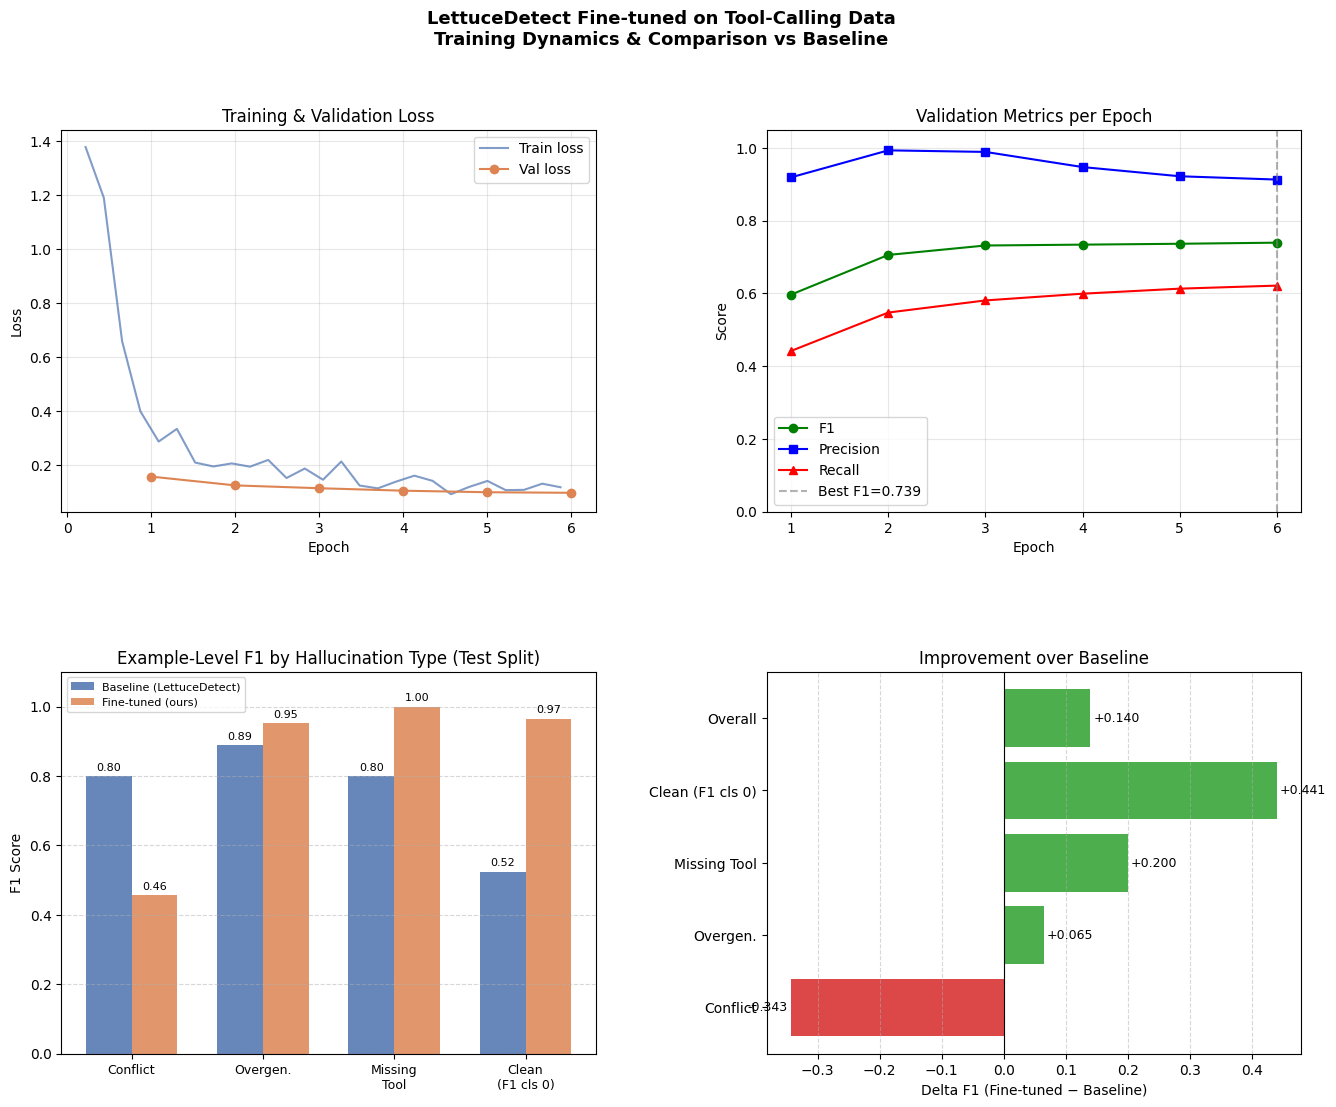

Saved → results/baseline_vs_finetuned.png


In [ ]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# ── 1: Training & Validation Loss ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
try:
    train_logs = [x for x in train_history if 'loss' in x and 'eval_loss' not in x]
    eval_logs  = [x for x in train_history if 'eval_loss' in x]
    if train_logs:
        ax1.plot([x['epoch'] for x in train_logs],
                 [x['loss']  for x in train_logs],
                 color='#4C72B0', alpha=0.7, label='Train loss')
    if eval_logs:
        ax1.plot([x['epoch']      for x in eval_logs],
                 [x['eval_loss']  for x in eval_logs],
                 'o-', color='#DD8452', label='Val loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Training & Validation Loss')
    ax1.legend(); ax1.grid(alpha=0.3)
except NameError:
    ax1.text(0.5, 0.5, 'train_history not found\nRe-run training cell',
             ha='center', va='center', transform=ax1.transAxes)

# ── 2: Validation Metrics per Epoch ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
try:
    if eval_logs:
        ep = [x['epoch'] for x in eval_logs]
        ax2.plot(ep, [x.get('eval_f1', 0)        for x in eval_logs], 'g-o', label='F1')
        ax2.plot(ep, [x.get('eval_precision', 0) for x in eval_logs], 'b-s', label='Precision')
        ax2.plot(ep, [x.get('eval_recall', 0)    for x in eval_logs], 'r-^', label='Recall')
        best_ep = max(eval_logs, key=lambda x: x.get('eval_f1', 0))
        ax2.axvline(best_ep['epoch'], color='gray', linestyle='--', alpha=0.6,
                    label=f'Best F1={best_ep["eval_f1"]:.3f}')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score')
    ax2.set_title('Validation Metrics per Epoch')
    ax2.set_ylim(0, 1.05); ax2.legend(); ax2.grid(alpha=0.3)
except (NameError, UnboundLocalError):
    ax2.text(0.5, 0.5, 'No eval logs', ha='center', va='center', transform=ax2.transAxes)

# ── 3: F1 Comparison per Type ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
plot_types  = [r[0] for r in table_rows if r[0] != 'overall']
xlabels     = ['Conflict', 'Overgen.', 'Missing\nTool', 'Clean\n(F1 cls 0)']
x = np.arange(len(plot_types)); w = 0.35
bl_f1s = [bl_metrics.get(t, {}).get('f1', 0)     for t in plot_types]
ft_f1s = [ft_metrics_ex.get(t, {}).get('f1', 0)  for t in plot_types]
b1 = ax3.bar(x - w/2, bl_f1s, w, label='Baseline (LettuceDetect)', color='#4C72B0', alpha=0.85)
b2 = ax3.bar(x + w/2, ft_f1s, w, label='Fine-tuned (ours)',         color='#DD8452', alpha=0.85)
ax3.set_xticks(x); ax3.set_xticklabels(xlabels, fontsize=9)
ax3.set_ylabel('F1 Score'); ax3.set_title('Example-Level F1 by Hallucination Type (Test Split)')
ax3.set_ylim(0, 1.10); ax3.legend(fontsize=8); ax3.grid(axis='y', linestyle='--', alpha=0.5)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0.02:
        ax3.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                 f'{h:.2f}', ha='center', va='bottom', fontsize=8)

# ── 4: Delta (improvement) ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
deltas  = [r[3] for r in table_rows]
dlabels = ['Conflict', 'Overgen.', 'Missing Tool', 'Clean (F1 cls 0)', 'Overall']
colors  = ['#2ca02c' if d >= 0 else '#d62728' for d in deltas]
bars    = ax4.barh(dlabels, deltas, color=colors, alpha=0.85)
ax4.axvline(0, color='black', linewidth=0.8)
ax4.set_xlabel('Delta F1 (Fine-tuned − Baseline)')
ax4.set_title('Improvement over Baseline')
ax4.grid(axis='x', linestyle='--', alpha=0.5)
for bar, d in zip(bars, deltas):
    ax4.text(d + (0.005 if d >= 0 else -0.005),
             bar.get_y() + bar.get_height() / 2,
             f'{d:+.3f}', va='center',
             ha='left' if d >= 0 else 'right', fontsize=9)

plt.suptitle(
    'LettuceDetect Fine-tuned on Tool-Calling Data\n'
    'Training Dynamics & Comparison vs Baseline',
    fontsize=13, fontweight='bold')
plt.savefig('results/baseline_vs_finetuned.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/baseline_vs_finetuned.png')

## Full-Data Summary & Hybrid Approach
Baseline was evaluated on all 1200 examples. Fine-tuned was evaluated on the 180-example test split.
The **hybrid** model routes each example to the better detector per hallucination type:
- Conflict + Overgeneration → Baseline (LettuceDetect)
- Missing Tool + Clean → Fine-tuned


In [ ]:

htypes_all = ['conflict', 'overgeneration', 'missing_tool', 'clean']
bl_all_metrics = {}
for htype in htypes_all:
    pos_lbl  = 0 if htype == 'clean' else 1
    type_ids = set(df_new[df_new['hallucination_type'] == htype]['id'])
    sub      = [r for r in evaluation_results_new if r['id'] in type_ids]
    y_true   = [1 if r['original_hallucination_labels'] else 0 for r in sub]
    y_pred   = [1 if len(r['detector_predictions']) > 0 else 0 for r in sub]
    p, r_, f, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', pos_label=pos_lbl, zero_division=0)
    bl_all_metrics[htype] = {'f1': f, 'n': len(sub)}

y_t = [1 if r['original_hallucination_labels'] else 0 for r in evaluation_results_new]
y_p = [1 if len(r['detector_predictions']) > 0 else 0 for r in evaluation_results_new]
p, r_, f, _ = precision_recall_fscore_support(y_t, y_p, average='binary', zero_division=0)
bl_all_metrics['overall'] = {'f1': f, 'n': len(evaluation_results_new)}

ft_test_metrics = ft_metrics_ex.copy()

print('=' * 72)
print(f'{"Type":18s}  {"Baseline (all 1200)":>20}  {"Fine-tuned (test 180)":>22}')
print('=' * 72)
order = ['conflict', 'overgeneration', 'missing_tool', 'clean', 'overall']
note  = {'clean': ' *'}
better = {}
for ht in order:
    bl_f = bl_all_metrics.get(ht, {}).get('f1', float('nan'))
    ft_f = ft_test_metrics.get(ht, {}).get('f1', float('nan'))
    win  = 'BL ◄' if bl_f > ft_f else 'FT ◄'
    better[ht] = 'baseline' if bl_f > ft_f else 'finetuned'
    tag  = note.get(ht, '')
    print(f'{ht+tag:18s}  {bl_f:>20.4f}  {ft_f:>22.4f}  {win}')
print('* clean: F1 for class 0 (correctly identified as NOT hallucinated)')
print()
print('Winner per type:', {k: v for k, v in better.items() if k != 'overall'})

Type                 Baseline (all 1200)   Fine-tuned (test 180)
conflict                          0.8636                  0.4571  BL ◄
overgeneration                    0.8991                  0.9535  FT ◄
missing_tool                      0.8258                  1.0000  FT ◄
clean *                           0.5915                  0.9655  FT ◄
overall                           0.7782                  0.8785  FT ◄
* clean: F1 for class 0 (correctly identified as NOT hallucinated)

Winner per type: {'conflict': 'baseline', 'overgeneration': 'finetuned', 'missing_tool': 'finetuned', 'clean': 'finetuned'}


Baseline types: ['conflict']
Fine-tuned types: ['overgeneration', 'missing_tool', 'clean']

Type                  Baseline    Fine-tuned    Hybrid   Best
----------------------------------------------------------------
conflict                0.8000        0.4571    0.8000     BL
overgeneration          0.8889        0.9535    0.9535     FT
missing_tool            0.8000        1.0000    1.0000     FT
clean *                 0.5246        0.9655    0.9655     FT
overall                 0.7385        0.8785    0.9134     HY


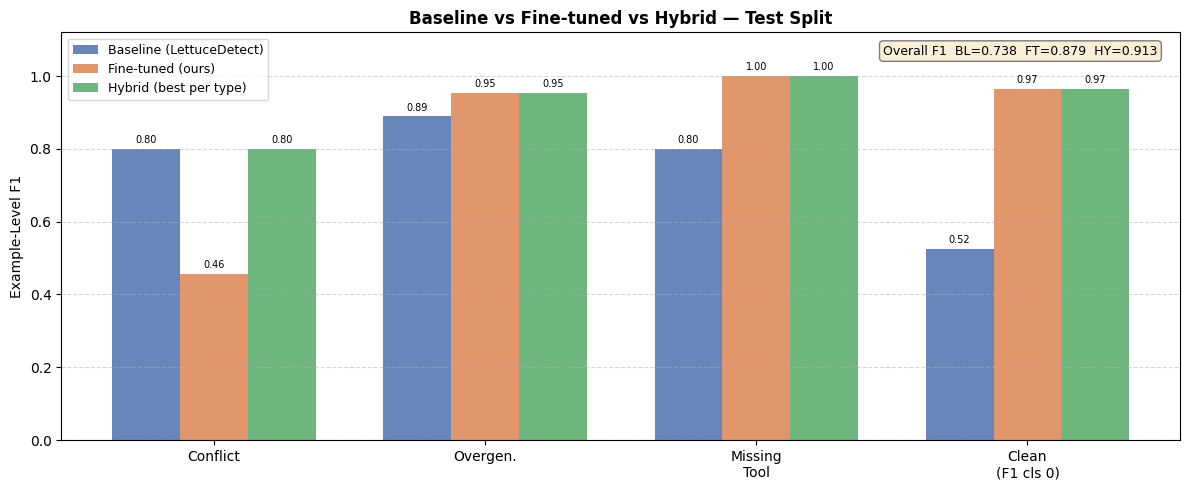

Saved → results/hybrid_comparison.png


In [ ]:

USE_BASELINE_FOR = [ht for ht, w in better.items() if w == 'baseline' and ht != 'overall']
USE_FT_FOR       = [ht for ht, w in better.items() if w == 'finetuned' and ht != 'overall']
print(f'Baseline types: {USE_BASELINE_FOR}')
print(f'Fine-tuned types: {USE_FT_FOR}')

bl_by_id = {r['id']: r for r in bl_test}
test_df_r = test_df.reset_index(drop=True)

hybrid_metrics = {}
all_hy_true, all_hy_pred = [], []

for htype in htypes_all:
    pos_lbl  = 0 if htype == 'clean' else 1
    type_ids = set(test_df[test_df['hallucination_type'] == htype]['id'])

    if htype in USE_BASELINE_FOR:
        sub    = [r for r in bl_test if r['id'] in type_ids]
        y_true = [1 if r['original_hallucination_labels'] else 0 for r in sub]
        y_pred = [1 if len(r['detector_predictions']) > 0 else 0 for r in sub]
    else:
        sub    = [r for r in ft_results if r['type'] == htype]
        y_true = [1 if any(l == 1 for l in r['y_true']) else 0 for r in sub]
        y_pred = [1 if any(p_ == 1 for p_ in r['y_pred']) else 0 for r in sub]

    all_hy_true.extend(y_true); all_hy_pred.extend(y_pred)
    p, r_, f, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', pos_label=pos_lbl, zero_division=0)
    hybrid_metrics[htype] = {'f1': f}

p, r_, f, _ = precision_recall_fscore_support(
    all_hy_true, all_hy_pred, average='binary', zero_division=0)
hybrid_metrics['overall'] = {'f1': f}


print(f'\n{"Type":18s}  {"Baseline":>10}  {"Fine-tuned":>12}  {"Hybrid":>8}  {"Best":>5}')
print('-' * 64)
hybrid_rows = []
for ht in order:
    bl_f = bl_metrics.get(ht, {}).get('f1', float('nan'))    # test-split baseline
    ft_f = ft_metrics_ex.get(ht, {}).get('f1', float('nan'))
    hy_f = hybrid_metrics.get(ht, {}).get('f1', float('nan'))
    best = max([(bl_f,'BL'),(ft_f,'FT'),(hy_f,'HY')], key=lambda x: x[0])[1]
    tag  = note.get(ht, '')
    hybrid_rows.append((ht, bl_f, ft_f, hy_f))
    print(f'{ht+tag:18s}  {bl_f:>10.4f}  {ft_f:>12.4f}  {hy_f:>8.4f}  {best:>5}')


fig, ax = plt.subplots(figsize=(12, 5))
plot_t  = [r[0] for r in hybrid_rows if r[0] != 'overall']
xlbls   = ['Conflict', 'Overgen.', 'Missing\nTool', 'Clean\n(F1 cls 0)']
x = np.arange(len(plot_t)); w = 0.25
bl_f1s = [bl_metrics.get(t, {}).get('f1', 0)    for t in plot_t]
ft_f1s = [ft_metrics_ex.get(t, {}).get('f1', 0) for t in plot_t]
hy_f1s = [hybrid_metrics.get(t, {}).get('f1', 0) for t in plot_t]
b1 = ax.bar(x - w, bl_f1s, w, label='Baseline (LettuceDetect)', color='#4C72B0', alpha=0.85)
b2 = ax.bar(x,     ft_f1s, w, label='Fine-tuned (ours)',         color='#DD8452', alpha=0.85)
b3 = ax.bar(x + w, hy_f1s, w, label='Hybrid (best per type)',    color='#55A868', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(xlbls, fontsize=10)
ax.set_ylabel('Example-Level F1'); ax.set_ylim(0, 1.12)
ax.set_title('Baseline vs Fine-tuned vs Hybrid — Test Split', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.5)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.02:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=7)
bl_ov = bl_metrics.get('overall',{}).get('f1',0)
ft_ov = ft_metrics_ex.get('overall',{}).get('f1',0)
hy_ov = hybrid_metrics.get('overall',{}).get('f1',0)
ax.text(0.98, 0.97,
        f'Overall F1  BL={bl_ov:.3f}  FT={ft_ov:.3f}  HY={hy_ov:.3f}',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.savefig('results/hybrid_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/hybrid_comparison.png')

In [ ]:
LOAD_DIR = '/content/lettuce_ft/checkpoint-525'

model_ft = AutoModelForTokenClassification.from_pretrained(LOAD_DIR).to(DEVICE)
tokenizer_ft = AutoTokenizer.from_pretrained(LOAD_DIR)

print(f'Model and tokenizer loaded from {LOAD_DIR}')

# Push to HuggingFace Hub
HF_REPO = 'annnettte/lettucedect-tool-calling'

model_ft.push_to_hub(HF_REPO)
tokenizer_ft.push_to_hub(HF_REPO)

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

Model and tokenizer loaded from /content/lettuce_ft/checkpoint-525


In [ ]:
from huggingface_hub import login

HF_REPO = 'annnettte/lettucedect-tool-calling'

# Please replace 'YOUR_HF_TOKEN' with your actual Hugging Face token
# You can create one in your Hugging Face settings: https://huggingface.co/settings/tokens
login(token='YOUR_HF_TOKEN')

model_ft.push_to_hub(HF_REPO)
tokenizer_ft.push_to_hub(HF_REPO)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...6bu2hkd/model.safetensors:  15%|#4        | 88.7MB /  598MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/annnettte/lettucedect-tool-calling/commit/9c3854add38ad70b67c5d8f2fd2ff2f056c86527', commit_message='Upload tokenizer', commit_description='', oid='9c3854add38ad70b67c5d8f2fd2ff2f056c86527', pr_url=None, repo_url=RepoUrl('https://huggingface.co/annnettte/lettucedect-tool-calling', endpoint='https://huggingface.co', repo_type='model', repo_id='annnettte/lettucedect-tool-calling'), pr_revision=None, pr_num=None)